<a href="https://colab.research.google.com/github/takeonakamura6-design/so/blob/main/Swapping_Troca_de_processos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Swapping: Troca de processos

TABELA DE RESULTADOS DO EXPERIMENTO:
Algoritmo  Fragmentação Total (Unidades)
first_fit                            647
 best_fit                            433
worst_fit                            747


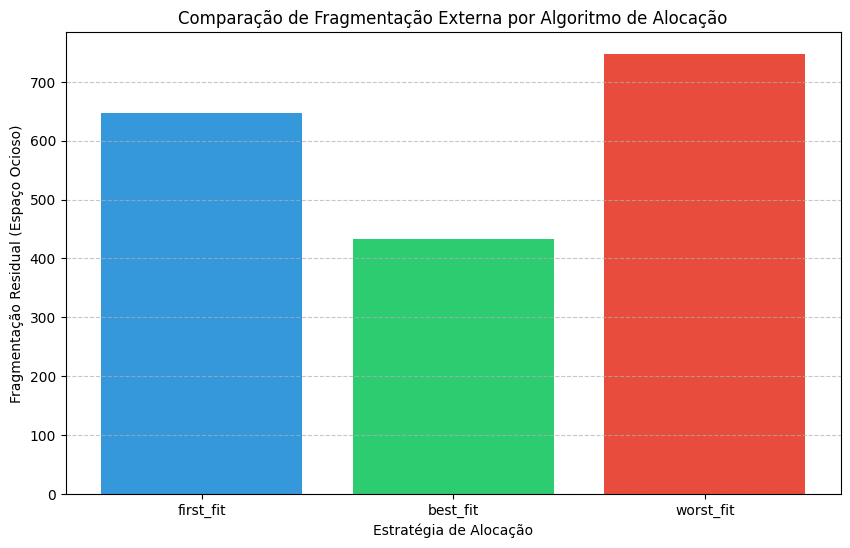


[INFO] Gráfico salvo como 'grafico.png'. Experimento concluído com sucesso.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def simular_alocacao(blocos_originais, processos, algoritmo="first_fit"):
    # Reinicia o estado da memória para cada simulação
    blocos = list(blocos_originais)
    alocacao = [-1] * len(processos)
    fragmentos = [0] * len(processos)

    for i in range(len(processos)):
        idx_escolhido = -1

        if algoritmo == "first_fit":
            for j in range(len(blocos)):
                if blocos[j] >= processos[i]:
                    idx_escolhido = j
                    break

        elif algoritmo == "best_fit":
            melhor_idx = -1
            for j in range(len(blocos)):
                if blocos[j] >= processos[i]:
                    if melhor_idx == -1 or blocos[j] < blocos[melhor_idx]:
                        melhor_idx = j
            idx_escolhido = melhor_idx

        elif algoritmo == "worst_fit":
            pior_idx = -1
            for j in range(len(blocos)):
                if blocos[j] >= processos[i]:
                    if pior_idx == -1 or blocos[j] > blocos[pior_idx]:
                        pior_idx = j
            idx_escolhido = pior_idx

        if idx_escolhido != -1:
            alocacao[i] = idx_escolhido
            fragmentos[i] = blocos[idx_escolhido] - processos[i]
            blocos[idx_escolhido] -= processos[i] # Atualiza espaço restante

    return sum(fragmentos)

# Configuração do Experimento
blocos_memoria = [100, 500, 200, 300, 600]
requisicoes_processos = [212, 417, 112, 426]
estrategias = ["first_fit", "best_fit", "worst_fit"]

# Execução e Coleta de Dados
resultados = {}
for est in estrategias:
    frag_total = simular_alocacao(blocos_memoria, requisicoes_processos, est)
    resultados[est] = frag_total

# Formatação em DataFrame para o Artigo
df = pd.DataFrame(list(resultados.items()), columns=['Algoritmo', 'Fragmentação Total (Unidades)'])
print("TABELA DE RESULTADOS DO EXPERIMENTO:")
print(df.to_string(index=False))

# Geração do Gráfico Científico
plt.figure(figsize=(10, 6))
cores = ['#3498db', '#2ecc71', '#e74c3c']
plt.bar(df['Algoritmo'], df['Fragmentação Total (Unidades)'], color=cores)
plt.title('Comparação de Fragmentação Externa por Algoritmo de Alocação')
plt.xlabel('Estratégia de Alocação')
plt.ylabel('Fragmentação Residual (Espaço Ocioso)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Salvando para publicação no Zenodo
plt.savefig('grafico.png')
plt.show()

print("\n[INFO] Gráfico salvo como 'grafico.png'. Experimento concluído com sucesso.")